In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Networks

## Session 08c
## Introduction to Pytorch - Framework Demo
- one hidden layer 
- ${tanh}$ activation function
- multi-class output
- FIFA dataset
- pytorch implementation Custom Dataset Class with loader


<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com" align="left"/>

In [2]:
###-----------------
### Import Libraries
###-----------------

import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Optional
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix

I0000 00:00:1778556242.143566   11269 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('../../input')
outDir = Path('../output')
modelDir = Path('../models')
modelSubDir = 'pytorch_fifa'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
torch.manual_seed(RANDOM_STATE) # Set Random Seed for reproducible  results

EPOCHS = 51 # number of epochs. Print values upto 50
BATCH_SIZE = 32
ALPHA = 0.001 # learning rate
VALID_SIZE = 0.2 # 0.2 is valid size to be kept aside for final testing
TRAIN_SIZE = 364 *32 # 364 batches of 32
# parameters for Matplotlib
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 10),
          'axes.labelsize': 'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params)

In [4]:
# Check if all directories are present
if not outDir.exists():
    outDir.mkdir(parents=True, exist_ok=True)
    print ('Created {} directory'.format(outDir))

if not modelDir.joinpath(modelSubDir).exists():
    modelDir.joinpath(modelSubDir).mkdir(parents=True, exist_ok=True)
    print ('Created {} directory'.format(modelDir.joinpath(modelSubDir)))

## Read FIFA 2019 data set
<img src = '../../images/fifa_2019.png' alt = 'Fifa 2019'>

In [5]:
data_df = pd.read_csv(inpDir/ 'fifa_2019.csv')
data_df.shape

(18207, 89)

In [6]:
18207*.64/32

364.14

In [7]:
# removing rows with position == null
data_df = data_df[data_df["Position"].notnull()]
data_df.head()

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [8]:
# Following columns appear to be relevant for our analysis
rel_cols = ["Position", 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
            'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
            'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
            'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
            'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
            'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
            'GKKicking', 'GKPositioning', 'GKReflexes']

In [9]:
# Keeping relevent columns.
data_df = data_df[rel_cols]
data_df.head()

,Position,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
0,RF,95.0,70.0,90.0,86.0,97.0,93.0,94.0,87.0,96.0,...,75.0,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0
1,ST,94.0,89.0,81.0,87.0,88.0,81.0,76.0,77.0,94.0,...,85.0,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0
2,LW,87.0,62.0,84.0,84.0,96.0,88.0,87.0,78.0,95.0,...,81.0,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0
3,GK,13.0,21.0,50.0,13.0,18.0,21.0,19.0,51.0,42.0,...,40.0,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0
4,RCM,82.0,55.0,92.0,82.0,86.0,85.0,83.0,91.0,91.0,...,79.0,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0


In [10]:
goalkeeper = 'GK'
forward = ['ST', 'LW', 'RW', 'LF', 'RF', 'RS','LS', 'CF']
midfielder = ['CM','RCM','LCM', 'CDM','RDM','LDM', 'CAM', 'LAM', 'RAM', 'RM', 'LM']
defender = ['CB', 'RCB', 'LCB', 'LWB', 'RWB', 'LB', 'RB']

In [11]:
data_df['position_encoded'] = 0

#Assign labels to goalkeepers
data_df.loc[data_df["Position"] == "GK", "position_encoded"] = 0

#Defenders
data_df.loc[data_df["Position"].isin(defender), "position_encoded"] = 1

#Midfielders
data_df.loc[data_df["Position"].isin(midfielder), "position_encoded"] = 2

#Forward
data_df.loc[data_df["Position"].isin(forward), "position_encoded"] = 3

# Helps in preventing pandas from complaining while get_dummies
data_df['position_encoded'] = pd.to_numeric(data_df['position_encoded'], downcast="integer")

# Remove original col
data_df = data_df.drop("Position", axis = 1)


In [12]:
class_labels = {0: 'GK', 1: 'Defender', 2: 'Mid Fielder', 3 : 'Forward'}

### Split data in Train, test and validation  sets

In [13]:
# Split to separate validation set
train_test_df, valid_df = train_test_split( data_df,
                                            stratify=data_df['position_encoded'],
                                            test_size=VALID_SIZE,
                                            random_state=RANDOM_STATE)

train_df, test_df = train_test_split(train_test_df,
                                     stratify=train_test_df['position_encoded'],
                                     train_size= TRAIN_SIZE, 
                                     random_state=RANDOM_STATE )
train_df.shape, test_df.shape, valid_df.shape

((11648, 34), (2869, 34), (3630, 34))

#### Make sure to reset indecies

In [14]:
train_df = train_df.reset_index(drop=True)
train_df.head()

,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,position_encoded
0,55.0,81.0,74.0,44.0,62.0,59.0,51.0,77.0,73.0,62.0,...,80.0,77.0,84.0,82.0,6.0,7.0,12.0,11.0,14.0,1
1,44.0,31.0,44.0,36.0,52.0,43.0,37.0,43.0,48.0,62.0,...,42.0,23.0,25.0,27.0,12.0,9.0,10.0,8.0,12.0,2
2,8.0,10.0,20.0,9.0,9.0,8.0,17.0,16.0,21.0,37.0,...,54.0,18.0,13.0,12.0,61.0,77.0,76.0,70.0,73.0,0
3,59.0,63.0,76.0,44.0,68.0,68.0,68.0,74.0,76.0,62.0,...,73.0,69.0,70.0,66.0,7.0,10.0,15.0,8.0,14.0,2
4,35.0,49.0,61.0,31.0,55.0,42.0,33.0,45.0,60.0,55.0,...,51.0,53.0,56.0,52.0,13.0,11.0,14.0,11.0,11.0,2


In [15]:
test_df = test_df.reset_index(drop=True)
test_df.head()

,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,position_encoded
0,69.0,66.0,73.0,67.0,74.0,74.0,75.0,74.0,75.0,68.0,...,82.0,80.0,67.0,73.0,8.0,7.0,12.0,10.0,12.0,2
1,66.0,34.0,71.0,48.0,74.0,69.0,64.0,68.0,70.0,76.0,...,68.0,13.0,22.0,26.0,8.0,14.0,6.0,6.0,12.0,2
2,58.0,56.0,75.0,55.0,64.0,59.0,54.0,70.0,70.0,70.0,...,64.0,69.0,68.0,63.0,13.0,14.0,12.0,14.0,8.0,2
3,39.0,50.0,74.0,42.0,57.0,49.0,42.0,67.0,56.0,70.0,...,60.0,54.0,67.0,58.0,8.0,10.0,10.0,15.0,12.0,2
4,42.0,62.0,66.0,38.0,55.0,44.0,51.0,63.0,61.0,58.0,...,57.0,64.0,65.0,61.0,8.0,6.0,9.0,16.0,7.0,2


In [16]:
valid_df = valid_df.reset_index(drop=True)
valid_df.head()

,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,BallControl,Acceleration,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,position_encoded
0,66.0,33.0,72.0,55.0,81.0,69.0,65.0,61.0,79.0,86.0,...,68.0,23.0,26.0,30.0,12.0,14.0,16.0,6.0,10.0,2
1,71.0,43.0,68.0,43.0,72.0,74.0,69.0,70.0,78.0,70.0,...,66.0,39.0,26.0,16.0,14.0,14.0,13.0,6.0,8.0,2
2,67.0,43.0,61.0,49.0,65.0,48.0,35.0,44.0,65.0,73.0,...,47.0,49.0,13.0,19.0,9.0,12.0,15.0,12.0,13.0,2
3,55.0,37.0,69.0,45.0,67.0,50.0,51.0,64.0,62.0,74.0,...,61.0,55.0,61.0,57.0,13.0,7.0,10.0,8.0,12.0,2
4,25.0,82.0,61.0,20.0,51.0,25.0,33.0,63.0,60.0,35.0,...,67.0,77.0,78.0,70.0,15.0,12.0,13.0,14.0,15.0,1


## All about CUDA

In [17]:
print ('Is CUDA available: ', torch.cuda.is_available())

print ('CUDA version: ', torch.version.cuda )

print ('Current Device ID: ', torch.cuda.current_device())

print ('Name of the CUDA device: ', torch.cuda.get_device_name(torch.cuda.current_device()))

Is CUDA available:  True
CUDA version:  13.0
Current Device ID:  0
Name of the CUDA device:  NVIDIA GeForce RTX 3060 Laptop GPU


In [18]:
# Get cpu or gpu device for training.

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using {device} device")

Using cuda device


## Custom DataSet

In [19]:
'''
In this code, we define a custom dataset called FifaDS that takes 
a DataFrame as input. 

'''

class FifaDS(Dataset):
    
    def __init__(self, 
                 dataframe: pd.DataFrame, 
                 device : str = device,
                 scaler : Optional[StandardScaler] = None,
                 is_train: bool = True,
                 label_col: str = 'position_encoder'):
        
        self.df = dataframe
        self.device = device
        self.is_train = is_train
        self.scaler = scaler or StandardScaler()
        self.label_col = label_col
        
        if self.is_train:
            self.labels = self.df[label_col].to_numpy()
            X = self.df.drop(label_col, axis = 1)
            self.features = self.scaler.fit_transform(X) # fit transform train set 
        else:
            if scaler is None:
                raise ValueError("Test set requires pre-fitted scaler")
            self.labels = self.df[label_col]
            X = self.df.drop(label_col, axis = 1)
            self.features = self.scaler.transform(X) # transform only test set 
        
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        # Extract features and label from the dataframe row
        features = self.features[index]
        label = self.labels[index]
        
        # Convert to PyTorch tensors
        features = torch.tensor(features, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.int64)
        
        return features, label

### Train Dataset

In [20]:
label_col = 'position_encoded'
# prepare Train Data set
train_ds = FifaDS(train_df, is_train = True, label_col = label_col)

# Save the scaler
scaler = train_ds.scaler  # get StandardScale

scaler_path = modelDir/ modelSubDir/'fifa_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

### Test dataset

In [21]:
with open(scaler_path, 'rb') as f:
    loaded_scaler = pickle.load(f)

test_ds = FifaDS(test_df, scaler=loaded_scaler, is_train=False, label_col=label_col)

valid_ds = FifaDS(valid_df, scaler=loaded_scaler, is_train=False, label_col=label_col)


## Prepare Network

In [22]:
class Model(nn.Module):
    
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(input_dim,16)
        self.actv1 = nn.ReLU()
        self.layer2 = nn.Linear(16, 4)
        
    def forward(self, x):
        x = self.actv1(self.layer1(x))
        x = self.layer2(x)
        return x

net = Model(input_dim=train_df.shape[1]-1).to(device) # Create model on GPU
print (net)

Model(
  (layer1): Linear(in_features=33, out_features=16, bias=True)
  (actv1): ReLU()
  (layer2): Linear(in_features=16, out_features=4, bias=True)
)


In [23]:
# Define data loaders for the training and testing datasets
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=True)

In [24]:
# Define the loss function and optimizer
# Suitable for multi-class classification
loss_fn = nn.CrossEntropyLoss() # cross entropy loss

# Adam optimizer
# - lr: learning rate
# - net.parameters(): all trainable weights and biases of the model
optimizer = torch.optim.Adam(net.parameters(), lr=ALPHA)

# Lists to store metrics history for plotting
loss = []     # Training loss per epoch
tloss = []    # Test loss per epoch  
acc = []      # Training accuracy per epoch
tacc = []     # Test accuracy per epoch
n_epoch = []  # Epoch numbers (0 to EPOCHS-1)



# Train the model for multiple epochs

for epoch in range(EPOCHS):
    
    # TRAINING PHASE 
    net.train()  # Set model to training mode (enables dropout, batch norm updates)
    
    # Training loop
    train_loss = 0.0
    train_acc = 0.0
    
    for data in train_loader:
        
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        
        optimizer.zero_grad() # Zero out gradients from previous batch
        
        outputs = net(inputs) #  get raw logits shape: (batch_size, num_classes=4)
        
        preds = torch.argmax(outputs, dim = 1) # Get predicted class
        
        batch_loss = loss_fn(outputs, labels) # Loss between predictions and true labels

        # Accuracy for this batch
        batch_acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
        
        batch_loss.backward() # Gradients of loss w.r.t all model parameters
        
        optimizer.step() # Update parameters using computed gradients
        
        train_loss += batch_loss.item() * inputs.size(0)
        train_acc += batch_acc * inputs.size(0)
    
    train_loss /= len(train_ds)
    train_acc /= len(train_ds)
    
    loss.append(train_loss)
    acc.append(train_acc)
    
    # Testing loop
    test_loss = 0.0
    test_acc = 0.0
    
    net.eval() # Set model to evaluation mode (disables dropout, uses running stats)
    
    
    with torch.inference_mode(): # Disables gradient computation and autograd tracking
        
        for data in test_loader:
            
            inputs, labels = data
            inputs = inputs.to(device), labels.to(device)
            
            outputs = net(inputs) 
            
            preds = torch.argmax(outputs, dim = 1)
            
            batch_loss = loss_fn(outputs, labels)

            batch_acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
            
            test_loss += batch_loss.item() * inputs.size(0)
            test_acc += batch_acc * inputs.size(0)
        
        test_loss /= len(test_ds)
        test_acc /= len(test_ds)
    
        tloss.append(test_loss)
        tacc.append(test_acc)
    n_epoch.append(epoch)
    
    if epoch%5 == 0:
        print(f'At epoch {epoch} | Loss - train:{train_loss:.4f}, test:{test_loss:.4f} | Acc - train:{train_acc:.4f}, test:{test_acc:.4f}')

At epoch 0 | Loss - train:0.6621, test:0.3873 | Acc - train:0.7428, test:0.8330
At epoch 5 | Loss - train:0.2973, test:0.2956 | Acc - train:0.8792, test:0.8770
At epoch 10 | Loss - train:0.2857, test:0.2903 | Acc - train:0.8828, test:0.8777
At epoch 15 | Loss - train:0.2805, test:0.2894 | Acc - train:0.8844, test:0.8756
At epoch 20 | Loss - train:0.2769, test:0.2887 | Acc - train:0.8853, test:0.8794
At epoch 25 | Loss - train:0.2742, test:0.2890 | Acc - train:0.8872, test:0.8773
At epoch 30 | Loss - train:0.2722, test:0.2866 | Acc - train:0.8875, test:0.8818
At epoch 35 | Loss - train:0.2710, test:0.2864 | Acc - train:0.8874, test:0.8797
At epoch 40 | Loss - train:0.2688, test:0.2863 | Acc - train:0.8903, test:0.8836
At epoch 45 | Loss - train:0.2669, test:0.2880 | Acc - train:0.8898, test:0.8811
At epoch 50 | Loss - train:0.2664, test:0.2899 | Acc - train:0.8917, test:0.8787


In [25]:
loss_df = pd.DataFrame({'epoch' : n_epoch, 'loss' : loss, 'test_loss': tloss, 'acc' : acc, 'test_acc': tacc})
loss_df.head()

,epoch,loss,test_loss,acc,test_acc
0,0,0.662132,0.387276,0.742788,0.833043
1,1,0.355147,0.325502,0.855082,0.864064
2,2,0.321275,0.308447,0.869420,0.870338
3,3,0.308828,0.301235,0.874399,0.878703
4,4,0.301603,0.296969,0.874485,0.878703


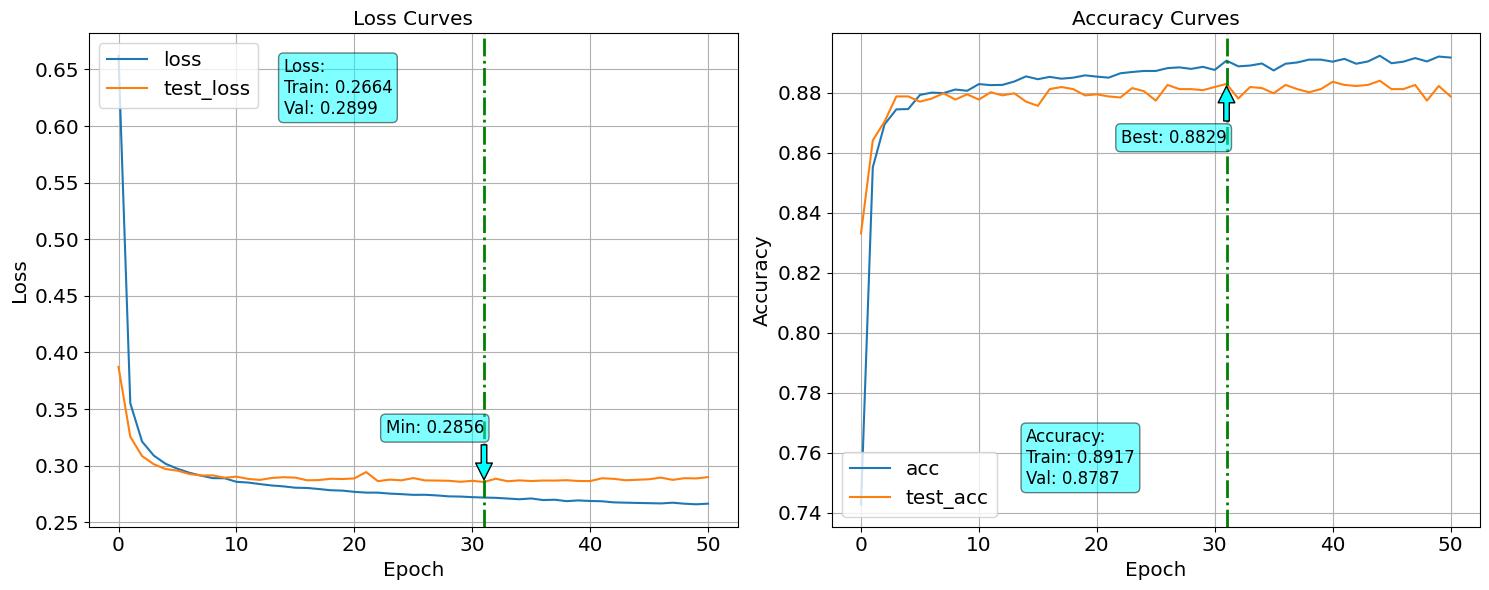

In [26]:
fn_plot_torch_hist(loss_df)

## Performance on Train Data

In [27]:
y_train = [] # True labels
y_pred = []  # Model prediction

for data in train_loader:
    
    inputs, labels = data
    
    inputs = inputs.to(device)
    
    outputs = net(inputs)
    
    preds = torch.argmax(outputs, dim = 1)

    y_train.extend(labels.numpy())

    y_pred.extend(preds.cpu().numpy())

In [28]:
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1300
           1       0.91      0.94      0.93      3765
           2       0.85      0.87      0.86      4389
           3       0.88      0.79      0.83      2194

    accuracy                           0.89     11648
   macro avg       0.91      0.90      0.90     11648
weighted avg       0.89      0.89      0.89     11648



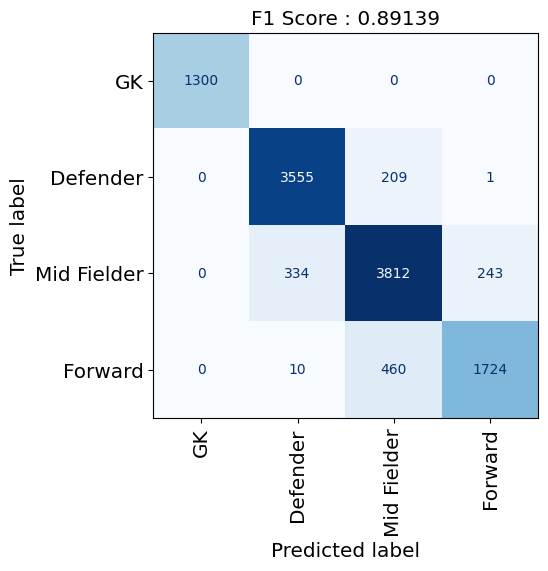

In [29]:
fn_plot_confusion_matrix(y_train, y_pred, class_labels)

## Performance on Test Data

In [30]:
y_test = []
y_pred = []
for data in test_loader:
    
    inputs, labels = data
    
    inputs = inputs.to(device)
    
    outputs = net(inputs)
    
    preds = torch.argmax(outputs, dim = 1)

    y_test.extend(labels.numpy())

    y_pred.extend(preds.cpu().numpy())

In [31]:
print(classification_report(y_test, y_pred ))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       320
           1       0.91      0.93      0.92       928
           2       0.83      0.86      0.84      1081
           3       0.86      0.76      0.80       540

    accuracy                           0.88      2869
   macro avg       0.90      0.89      0.89      2869
weighted avg       0.88      0.88      0.88      2869



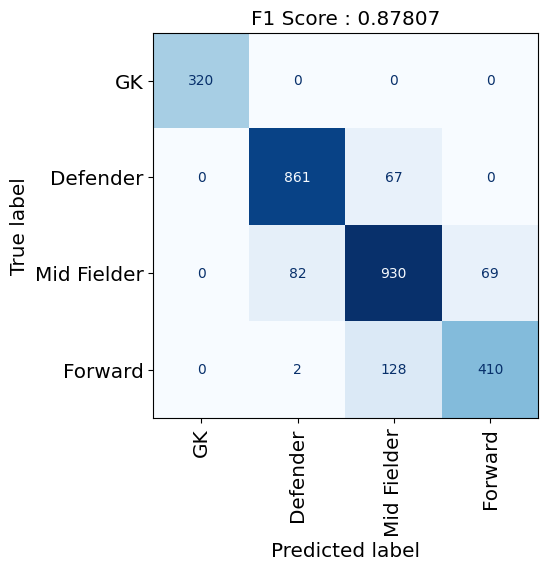

In [32]:
fn_plot_confusion_matrix(y_test, y_pred, class_labels)

### Performance on Valid Datatest

In [33]:
y_valid = []
y_pred = []

for data in valid_loader:
    
    inputs, labels = data
    
    inputs = inputs.to(device)
    
    outputs = net(inputs)
    
    preds = torch.argmax(outputs, dim = 1)

    y_valid.extend(labels.numpy())

    y_pred.extend(preds.cpu().numpy())

In [34]:
print(classification_report(y_valid, y_pred ))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       405
           1       0.90      0.93      0.92      1173
           2       0.82      0.85      0.84      1368
           3       0.84      0.73      0.78       684

    accuracy                           0.87      3630
   macro avg       0.89      0.88      0.88      3630
weighted avg       0.87      0.87      0.87      3630



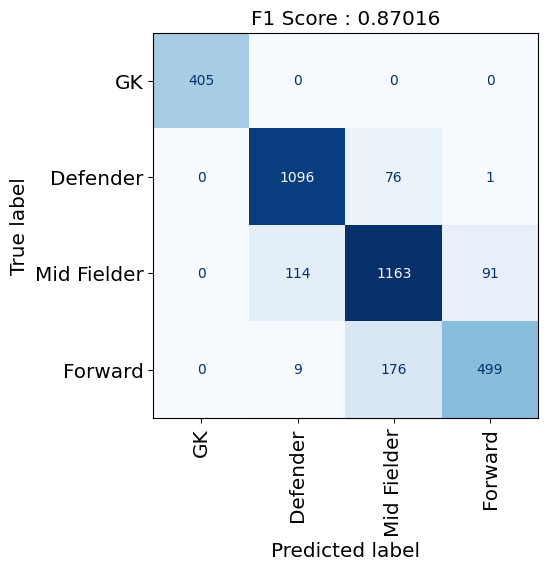

In [35]:
fn_plot_confusion_matrix(y_valid, y_pred, class_labels)